# Прогнозирование временных рядов (Bybit): единый Jupyter pipeline

Этот ноутбук переносит текущее решение в воспроизводимый формат:
- загрузка данных BTC/ETH с основного Bybit,
- очистка и предобработка,
- запуск моделей Naive / ARIMA,
- проверки, визуализация и экспорт результатов.

## 1) Подготовка окружения и зависимостей

Если чего-то не хватает, раскомментируй установку в ячейке ниже и перезапусти kernel.

In [34]:
# При необходимости установки (раскомментируй):
# %pip install pandas numpy requests statsmodels matplotlib seaborn torch

import sys
print('Python:', sys.version)

Python: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]


## 2) Импорт модулей и базовые настройки

Задаём импорты, параметры отображения и конфигурацию загрузки данных.

In [35]:
from __future__ import annotations

import importlib
import pandas as pd
import seaborn as sns
from pathlib import Path

from data_pipeline import DataConfig, DataProcessor, fetch_klines, build_datasets
import model_baselines as _mb
from export_utils import plot_result, export_all_results

# В ноутбуке иногда остаётся старый кэш модуля после правок файла — принудительно обновляем
_mb = importlib.reload(_mb)
run_naive = _mb.run_naive
run_arima = _mb.run_arima
run_sarima = _mb.run_sarima

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 160)
sns.set_theme(style='whitegrid')

CONFIG = DataConfig(
    base_url='https://api.bybit.com',
    interval='60',
    bars=3000,
    target_col='close',
    date_col='timestamp',
    test_ratio=0.2,
)

SYMBOLS = ['BTCUSDT', 'ETHUSDT']
OUTPUT_DIR = Path('data/outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## 3) Загрузка входных данных/файлов

Скачиваем свечи с Bybit API и проверяем структуру.

In [36]:
raw_data = {}
for symbol in SYMBOLS:
    raw_data[symbol] = fetch_klines(symbol, CONFIG)
    print(f"{symbol}: {len(raw_data[symbol])} rows")

raw_data['BTCUSDT'].head()

BTCUSDT: 3000 rows
ETHUSDT: 3000 rows


,timestamp,open,high,low,close,volume,turnover
0,2025-11-01 11:00:00+00:00,110120.0,110188.8,109938.2,110105.2,573.464,6.312915e+07
1,2025-11-01 12:00:00+00:00,110105.2,110164.4,109951.5,109967.9,420.349,4.625939e+07
2,2025-11-01 13:00:00+00:00,109967.9,110021.9,109661.7,109900.0,1055.789,1.159790e+08
3,2025-11-01 14:00:00+00:00,109900.0,109950.0,109669.3,109883.6,915.782,1.005541e+08
4,2025-11-01 15:00:00+00:00,109883.6,110327.3,109851.9,110254.1,1776.514,1.956713e+08


## 4) Очистка и предобработка данных

Убираем некорректные значения, нули и экстремальные выбросы по лог-доходности.

In [37]:
processor = DataProcessor(target_col=CONFIG.target_col, date_col=CONFIG.date_col)
cleaned_data = {}
reports = {}

for symbol, df in raw_data.items():
    clean_df, rep = processor.process(df)
    cleaned_data[symbol] = clean_df
    reports[symbol] = rep
    print(
        f"{symbol}: before={rep['initial_rows']} after={rep['final_rows']} removed={rep['removed_total']} "
        f"(zero/nonpos={rep['removed_nonpositive_or_zero']}, outliers={rep['removed_outliers']})"
    )

cleaned_data['BTCUSDT'].head()

BTCUSDT: before=3000 after=2990 removed=10 (zero/nonpos=0, outliers=10)
ETHUSDT: before=3000 after=2985 removed=15 (zero/nonpos=0, outliers=15)


,timestamp,open,high,low,close,volume,turnover
0,2025-11-01 11:00:00+00:00,110120.0,110188.8,109938.2,110105.2,573.464,6.312915e+07
1,2025-11-01 12:00:00+00:00,110105.2,110164.4,109951.5,109967.9,420.349,4.625939e+07
2,2025-11-01 13:00:00+00:00,109967.9,110021.9,109661.7,109900.0,1055.789,1.159790e+08
3,2025-11-01 14:00:00+00:00,109900.0,109950.0,109669.3,109883.6,915.782,1.005541e+08
4,2025-11-01 15:00:00+00:00,109883.6,110327.3,109851.9,110254.1,1776.514,1.956713e+08


## 5) Основная логика (функции и вычисления)

Разбиваем данные на train/test и реализуем запуск моделей.

In [38]:
datasets = build_datasets(cleaned_data, target_col=CONFIG.target_col, test_ratio=CONFIG.test_ratio)
for symbol, data in datasets.items():
    print(f"{symbol}: full={len(data['full'])} train={len(data['train'])} test={len(data['test'])}")

BTCUSDT: full=2990 train=2392 test=598
ETHUSDT: full=2985 train=2388 test=597


## 6) Проверка результата и отладочные проверки

Быстрые assert-проверки целостности данных и базового запуска.

In [39]:
for symbol in SYMBOLS:
    assert symbol in datasets, f'{symbol} отсутствует в datasets'
    assert len(datasets[symbol]['train']) > 10, f'{symbol}: слишком мало train данных'
    assert len(datasets[symbol]['test']) > 10, f'{symbol}: слишком мало test данных'
    assert (datasets[symbol]['full'] > 0).all(), f'{symbol}: есть неположительные значения после очистки'

print('Базовые проверки данных пройдены.')

# smoke-test на Naive
smoke_symbol = 'BTCUSDT'
smoke_metrics, smoke_pred = run_naive(datasets[smoke_symbol]['train'], datasets[smoke_symbol]['test'])
print('Smoke Naive metrics:', smoke_metrics)
smoke_pred.head()

Базовые проверки данных пройдены.
Smoke Naive metrics: {'MAE': 282.01321070234115, 'RMSE': 401.08707294502983, 'MAPE': 0.41644478353423175}


,y_true,y_pred
0,68690.0,69593.3
1,68900.0,68690.0
2,69106.5,68900.0
3,68556.4,69106.5
4,69230.5,68556.4


## 7) Визуализация результатов

Строим график исходного ряда и сравнение факта/прогноза для выбранной модели.

In [ ]:
# 1) Начальные данные
RUN_SYMBOL = 'BTCUSDT'  # BTCUSDT или ETHUSDT
ARIMA_ORDER = (1, 1, 1)
SARIMA_ORDER = (1, 1, 0)
SARIMA_SEASONAL_ORDER = (1, 1, 1, 24)

train = datasets[RUN_SYMBOL]['train']
test = datasets[RUN_SYMBOL]['test']
full = datasets[RUN_SYMBOL]['full']

ALL_RESULTS = {}

print(f'Готово к запуску моделей для {RUN_SYMBOL}')

Готово к запуску моделей для BTCUSDT


NAIVE: 0%
NAIVE: 100%
SYMBOL=BTCUSDT | MODEL=naive
Metrics: {'MAE': 282.01321070234115, 'RMSE': 401.08707294502983, 'MAPE': 0.41644478353423175}


,y_true,y_pred
0,68690.0,69593.3
1,68900.0,68690.0
2,69106.5,68900.0
3,68556.4,69106.5
4,69230.5,68556.4


,y_true,y_pred
593,70571.6,70400.4
594,71035.1,70571.6
595,70760.4,71035.1
596,70528.7,70760.4
597,70620.6,70528.7


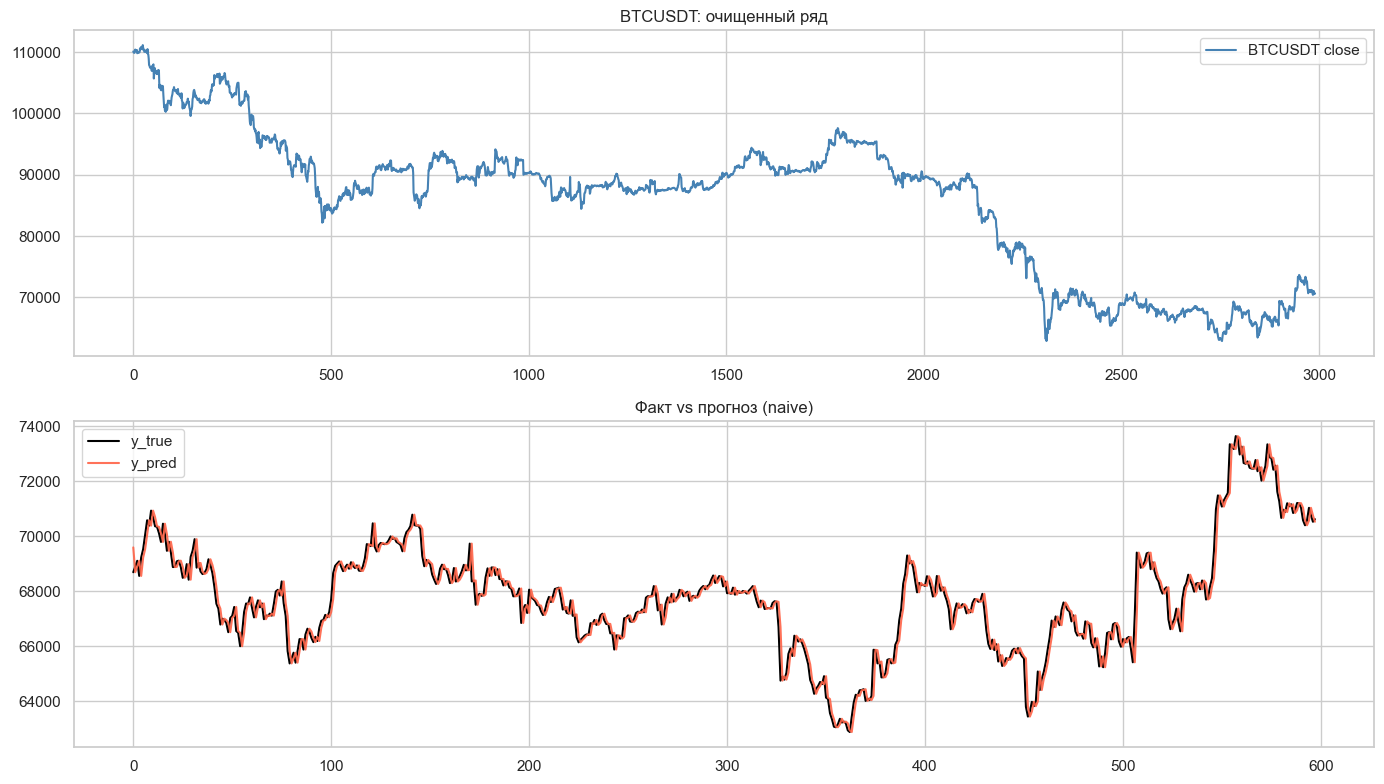

In [41]:
# 2) Модель Naive
RUN_MODEL = 'naive'
print('NAIVE: 0%')
model_metrics, pred_df = run_naive(train, test)
print('NAIVE: 100%')

ALL_RESULTS[RUN_MODEL] = {
    'metrics': model_metrics,
    'pred_df': pred_df.copy(),
    'symbol': RUN_SYMBOL,
}

print(f'SYMBOL={RUN_SYMBOL} | MODEL={RUN_MODEL}')
print('Metrics:', model_metrics)
display(pred_df.head())
display(pred_df.tail())

plot_result(RUN_SYMBOL, RUN_MODEL, full, pred_df)

ARIMA: 0%
ARIMA: 5%
ARIMA: 10%
ARIMA: 15%
ARIMA: 20%
ARIMA: 25%
ARIMA: 30%
ARIMA: 35%
ARIMA: 40%
ARIMA: 45%
ARIMA: 50%
ARIMA: 55%
ARIMA: 60%
ARIMA: 65%
ARIMA: 70%
ARIMA: 75%
ARIMA: 80%
ARIMA: 85%
ARIMA: 90%
ARIMA: 95%
ARIMA: 100%
SYMBOL=BTCUSDT | MODEL=arima
Metrics: {'MAE': 282.9086252039957, 'RMSE': 400.803042248191, 'MAPE': 0.4177234173551753}


,y_true,y_pred
0,68690.0,69567.516845
1,68900.0,68643.971105
2,69106.5,68875.426944
3,68556.4,69096.415089
4,69230.5,68532.046213


,y_true,y_pred
593,70571.6,70384.574403
594,71035.1,70572.036394
595,70760.4,71054.186741
596,70528.7,70757.080904
597,70620.6,70517.935564


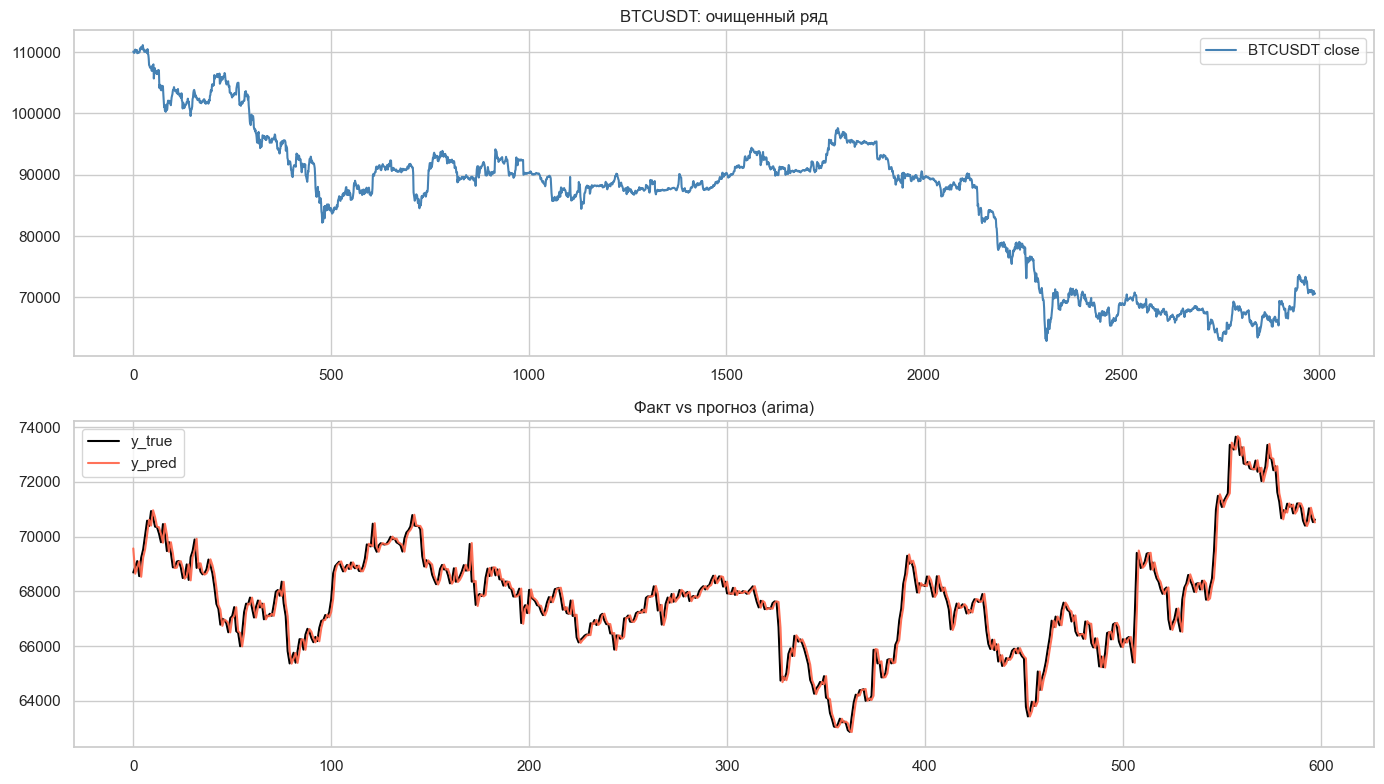

In [42]:
# 3) Модель ARIMA
RUN_MODEL = 'arima'
model_metrics, pred_df = run_arima(train, test, order=ARIMA_ORDER, show_progress=True)

ALL_RESULTS[RUN_MODEL] = {
    'metrics': model_metrics,
    'pred_df': pred_df.copy(),
    'symbol': RUN_SYMBOL,
}

print(f'SYMBOL={RUN_SYMBOL} | MODEL={RUN_MODEL}')
print('Metrics:', model_metrics)
display(pred_df.head())
display(pred_df.tail())

plot_result(RUN_SYMBOL, RUN_MODEL, full, pred_df)

SARIMA (statsmodels) работает на CPU; CUDA для него не поддерживается.
SARIMA: 0%
SARIMA: 5%
SARIMA: 10%
SARIMA: 15%
SARIMA: 20%
SARIMA: 25%
SARIMA: 30%
SARIMA: 35%
SARIMA: 40%
SARIMA: 45%
SARIMA: 50%
SARIMA: 55%
SARIMA: 60%
SARIMA: 65%
SARIMA: 70%
SARIMA: 75%
SARIMA: 80%
SARIMA: 85%
SARIMA: 90%
SARIMA: 95%
SARIMA: 100%
SARIMA: 100%
SYMBOL=BTCUSDT | MODEL=sarima
Metrics: {'MAE': 355.8940312909644, 'RMSE': 500.49541244743676, 'MAPE': 0.5253508387075362}


,y_true,y_pred
0,68690.0,69610.211120
1,68900.0,68976.095098
2,69106.5,69547.783167
3,68556.4,69245.872806
4,69230.5,68173.409414


,y_true,y_pred
593,70571.6,70610.676743
594,71035.1,70847.017733
595,70760.4,71964.558667
596,70528.7,71066.492989
597,70620.6,70780.104186


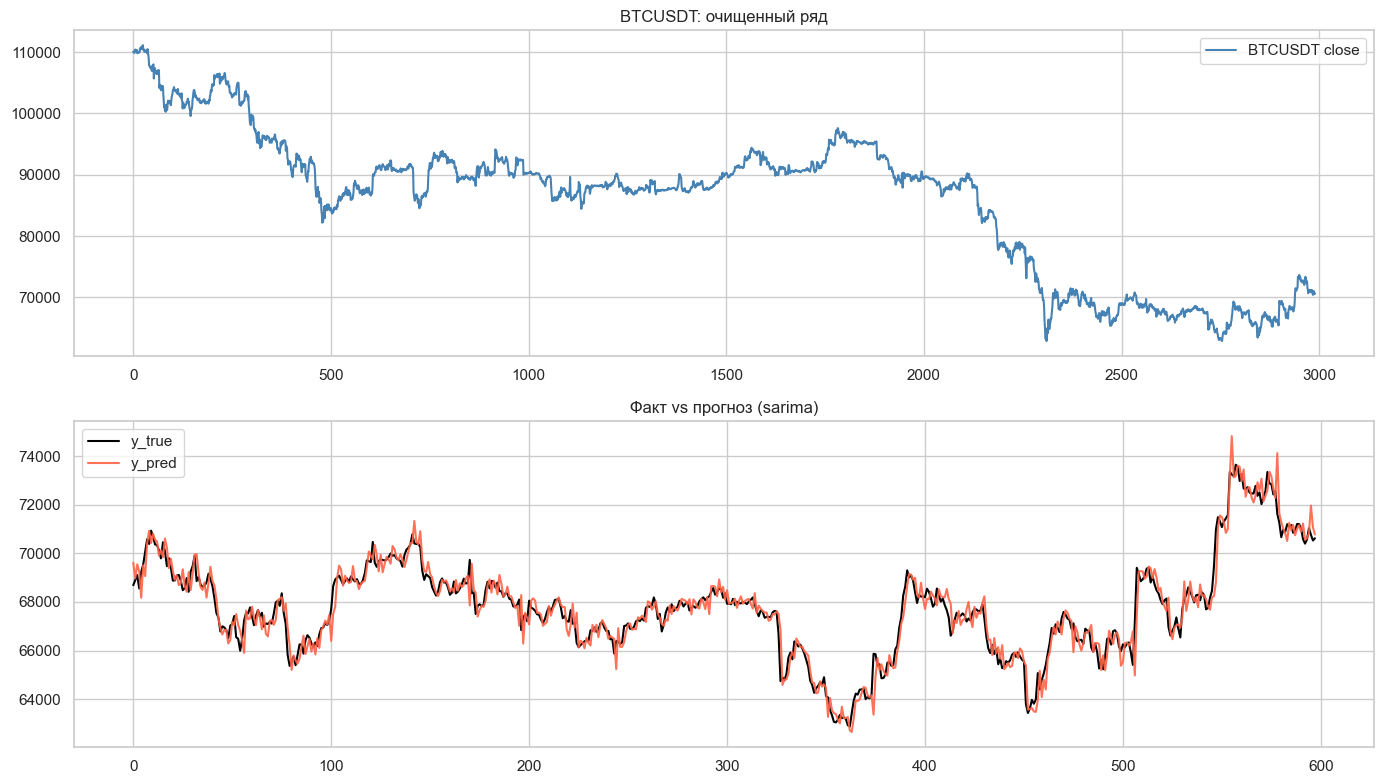

In [43]:
# 3.2) Модель SARIMA (облегчённая rolling-конфигурация, без fast_mode)
import importlib
import model_baselines as _mb_local

_mb_local = importlib.reload(_mb_local)
run_sarima = _mb_local.run_sarima

RUN_MODEL = 'sarima'
model_metrics, pred_df = run_sarima(
    train,
    test,
    order=SARIMA_ORDER,
    seasonal_order=SARIMA_SEASONAL_ORDER,
    refit_every=48,
    fit_window=1000,
    maxiter=50,
    show_progress=True,
    use_cuda=True,  # напоминание: функция выведет, что statsmodels-SARIMA работает на CPU
)

ALL_RESULTS[RUN_MODEL] = {
    'metrics': model_metrics,
    'pred_df': pred_df.copy(),
    'symbol': RUN_SYMBOL,
}

print(f'SYMBOL={RUN_SYMBOL} | MODEL={RUN_MODEL}')
print('Metrics:', model_metrics)
display(pred_df.head())
display(pred_df.tail())

plot_result(RUN_SYMBOL, RUN_MODEL, full, pred_df)

torch=2.5.1+cu121 | torch.cuda=12.1 | cuda_available=True


CUDA device: NVIDIA GeForce RTX 4080
AST device: cuda | AMP=True | GAN=True | train_windows=2224
AST: 0%
AST: 2% | lr=0.000599
AST: 5% | lr=0.000595
AST: 8% | lr=0.000589
AST: 11% | lr=0.000581
AST: 14% | lr=0.000571
AST: 17% | lr=0.000558
AST: 20% | lr=0.000544
AST: 22% | lr=0.000527
AST: 25% | lr=0.000509
AST: 28% | lr=0.000489
AST: 31% | lr=0.000468
AST: 34% | lr=0.000445
AST: 37% | lr=0.000421
AST: 40% | lr=0.000396
AST: 42% | lr=0.000371
AST: 45% | lr=0.000345
AST: 48% | lr=0.000318
AST: 51% | lr=0.000292
AST: 54% | lr=0.000265
AST: 57% | lr=0.000239
AST: 60% | lr=0.000214
AST: 62% | lr=0.000189
AST: 65% | lr=0.000165
AST: 68% | lr=0.000142
AST: 71% | lr=0.000121
AST: 74% | lr=0.000101
AST: 77% | lr=0.000083
AST: 80% | lr=0.000066
AST: 82% | lr=0.000052
AST: 85% | lr=0.000039
AST: 88% | lr=0.000029
AST: 91% | lr=0.000021
AST: 94% | lr=0.000015
AST: 97% | lr=0.000011
AST: 100% | lr=0.000010
SYMBOL=BTCUSDT | MODEL=ast
Metrics: {'MAE': 793.8050882681163, 'RMSE': 905.9476392234972, '

,y_true,y_pred
0,68690.000055,69520.467041
1,68900.000108,68763.399063
2,69106.500303,68793.168665
3,68556.400816,68981.346256
4,69230.499533,68562.055313


,y_true,y_pred
593,70571.599859,69862.955512
594,71035.100199,69971.448309
595,70760.400630,70350.290371
596,70528.700004,70204.704536
597,70620.599806,70001.937868


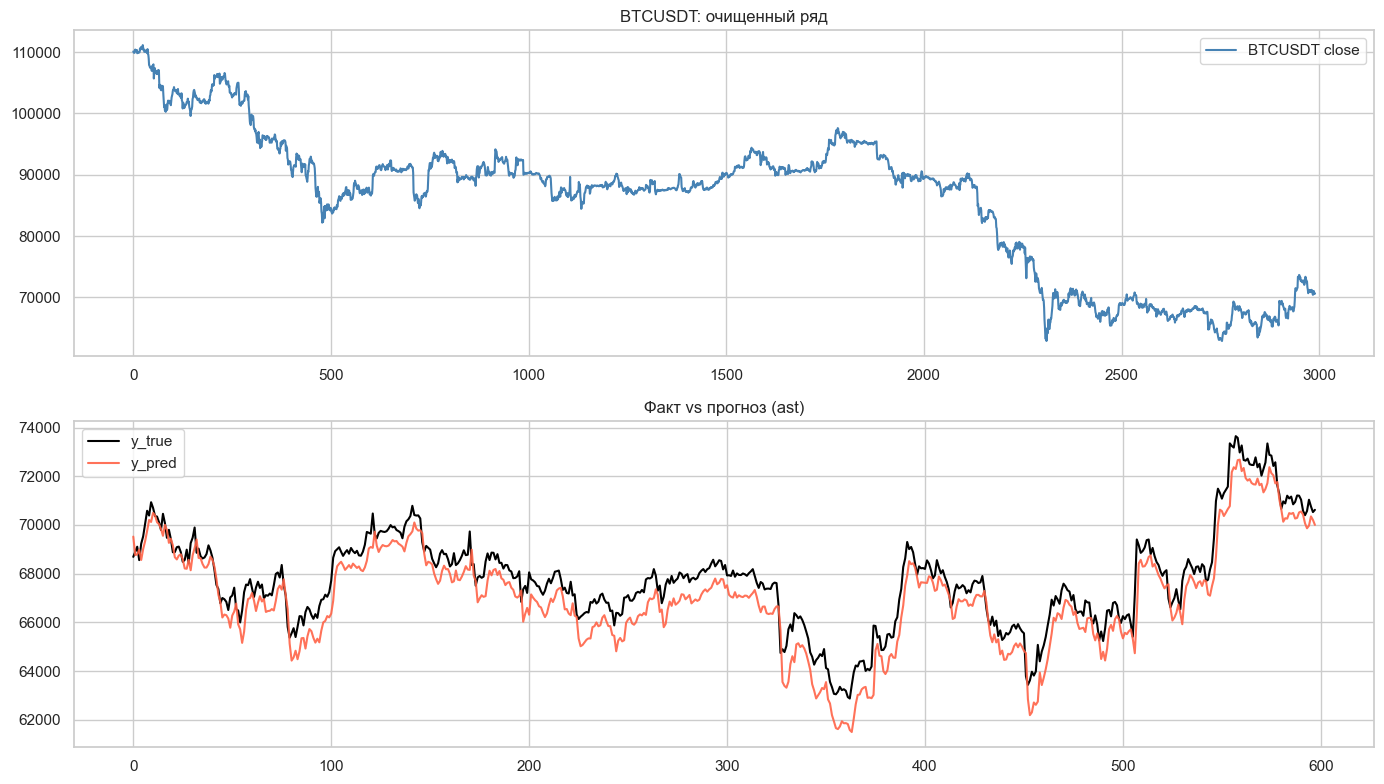

In [44]:
# 3.5) Модель AST (усиленная + стабильная версия: window scaling + adaptive GAN + AMP)
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader


class _AstSeriesDataset(Dataset):
    def __init__(self, series_scaled: np.ndarray, starts: np.ndarray, context_len: int, pred_len: int):
        self.series = series_scaled.astype(np.float32)
        self.starts = starts.astype(np.int64)
        self.context_len = context_len
        self.pred_len = pred_len

    def __len__(self):
        return len(self.starts)

    def __getitem__(self, idx):
        s = int(self.starts[idx])
        x = self.series[s:s + self.context_len].astype(np.float32)
        y = self.series[s + self.context_len:s + self.context_len + self.pred_len].astype(np.float32)

        # Как в AST-main preprocess: нормализация по окну, чтобы убрать масштабный сдвиг режимов
        scale = float(np.mean(np.abs(x)) + 1.0)
        x = x / scale
        y = y / scale
        return torch.from_numpy(x[:, None]), torch.from_numpy(y), torch.tensor(scale, dtype=torch.float32)


class _SparseAttention(nn.Module):
    def __init__(self, d_model: int, n_heads: int, topk: int = 32, dropout: float = 0.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_head = d_model // n_heads
        self.topk = topk

        self.q = nn.Linear(d_model, d_model)
        self.k = nn.Linear(d_model, d_model)
        self.v = nn.Linear(d_model, d_model)
        self.o = nn.Linear(d_model, d_model)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        b, t, _ = x.shape
        q = self.q(x).view(b, t, self.n_heads, self.d_head).transpose(1, 2)
        k = self.k(x).view(b, t, self.n_heads, self.d_head).transpose(1, 2)
        v = self.v(x).view(b, t, self.n_heads, self.d_head).transpose(1, 2)

        scores = torch.matmul(q, k.transpose(-2, -1)) / (self.d_head ** 0.5)
        if self.topk > 0 and self.topk < t:
            topv, topi = torch.topk(scores, k=self.topk, dim=-1)
            sparse_scores = torch.full_like(scores, float('-inf'))
            sparse_scores.scatter_(-1, topi, topv)
            scores = sparse_scores

        attn = torch.softmax(scores, dim=-1)
        attn = self.drop(attn)
        out = torch.matmul(attn, v)
        out = out.transpose(1, 2).contiguous().view(b, t, self.d_model)
        return self.o(out)


class _AstBlock(nn.Module):
    def __init__(self, d_model=128, n_heads=8, ff_dim=256, topk=32, dropout=0.1):
        super().__init__()
        self.attn = _SparseAttention(d_model, n_heads, topk=topk, dropout=dropout)
        self.ff = nn.Sequential(
            nn.Linear(d_model, ff_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(ff_dim, d_model),
        )
        self.n1 = nn.LayerNorm(d_model)
        self.n2 = nn.LayerNorm(d_model)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        x = self.n1(x + self.drop(self.attn(x)))
        x = self.n2(x + self.drop(self.ff(x)))
        return x


class _AstGenerator(nn.Module):
    def __init__(self, context_len=96, pred_len=1, d_model=128, n_heads=8, n_layers=4, ff_dim=256, dropout=0.12, topk=32):
        super().__init__()
        self.pred_len = pred_len
        self.inp = nn.Linear(1, d_model)
        self.local_conv = nn.Conv1d(d_model, d_model, kernel_size=3, padding=1, groups=1)
        self.pos = nn.Parameter(torch.zeros(1, context_len, d_model))
        self.blocks = nn.ModuleList([_AstBlock(d_model, n_heads, ff_dim, topk=topk, dropout=dropout) for _ in range(n_layers)])
        self.out_norm = nn.LayerNorm(d_model)
        self.q10 = nn.Linear(d_model, pred_len)
        self.q50 = nn.Linear(d_model, pred_len)
        self.q90 = nn.Linear(d_model, pred_len)

    def forward(self, x):
        h = self.inp(x) + self.pos[:, :x.size(1), :]
        h_conv = self.local_conv(h.transpose(1, 2)).transpose(1, 2)
        h = h + h_conv
        for block in self.blocks:
            h = block(h)
        z = self.out_norm(h[:, -1, :])
        q10 = self.q10(z)
        q50 = self.q50(z)
        q90 = self.q90(z)
        return torch.stack([q10, q50, q90], dim=-1)  # [B, pred_len, 3]


class _AstDiscriminator(nn.Module):
    def __init__(self, total_len: int, hidden=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.utils.spectral_norm(nn.Linear(total_len, hidden)),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.15),
            nn.utils.spectral_norm(nn.Linear(hidden, hidden // 2)),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.1),
            nn.Linear(hidden // 2, 1),
        )

    def forward(self, seq):
        return self.net(seq)


def _pinball(pred, target, q):
    err = target - pred
    return torch.maximum(q * err, (q - 1.0) * err).mean()


def _q_loss(pred_q, y):
    q10 = pred_q[:, :, 0]
    q50 = pred_q[:, :, 1]
    q90 = pred_q[:, :, 2]
    l10 = _pinball(q10, y, 0.10)
    l50 = _pinball(q50, y, 0.50)
    l90 = _pinball(q90, y, 0.90)
    monotonic_penalty = torch.relu(q10 - q50).mean() + torch.relu(q50 - q90).mean()
    return 0.2 * l10 + 0.6 * l50 + 0.2 * l90 + 0.5 * monotonic_penalty


def run_ast_astmain_style(
    full_series: pd.Series,
    test_ratio=0.2,
    context_len=168,
    pred_len=1,
    epochs=35,
    batch_size=64,
    lr=6e-4,
    min_lr=1e-5,
    lambda_adv=0.008,
    d_steps=2,
    d_model=128,
    n_heads=8,
    n_layers=4,
    ff_dim=256,
    dropout=0.12,
    topk=48,
    seed=42,
    use_cuda=True,
    use_amp=True,
    use_gan='auto',
):
    torch.manual_seed(seed)
    np.random.seed(seed)

    values = pd.to_numeric(full_series, errors='coerce').astype(float).values
    values = values[np.isfinite(values)]
    values = np.clip(values, 1e-8, None)

    mean = float(values.mean())
    std = float(values.std() + 1e-8)
    scaled = (values - mean) / std

    n = len(scaled)
    max_start = n - context_len - pred_len
    starts = np.arange(0, max_start + 1, dtype=np.int64)

    test_size = max(10, int(n * test_ratio))
    split_point = n - test_size
    end_idx = starts + context_len + pred_len
    train_starts = starts[end_idx <= split_point]
    test_starts = starts[end_idx > split_point]

    if len(train_starts) < 24 or len(test_starts) < 8:
        raise RuntimeError('Слишком мало окон для AST')

    # adaptive-capacity для маленьких датасетов (weekly-чанки), чтобы не разваливаться
    small_data = len(train_starts) < 400
    if small_data:
        d_model = min(d_model, 96)
        n_heads = 4 if d_model % 4 == 0 else n_heads
        n_layers = min(n_layers, 2)
        ff_dim = min(ff_dim, 192)
        topk = min(topk, max(8, context_len // 3))

    if use_gan == 'auto':
        gan_enabled = len(train_starts) >= 800
    else:
        gan_enabled = bool(use_gan)

    train_ds = _AstSeriesDataset(scaled, train_starts, context_len, pred_len)
    test_ds = _AstSeriesDataset(scaled, test_starts, context_len, pred_len)

    cuda_exist = torch.cuda.is_available() and bool(use_cuda)
    if cuda_exist:
        torch.backends.cudnn.benchmark = True

    amp_enabled = cuda_exist and bool(use_amp)
    device = torch.device('cuda' if cuda_exist else 'cpu')
    amp_device_type = 'cuda' if cuda_exist else 'cpu'
    print(f"torch={torch.__version__} | torch.cuda={torch.version.cuda} | cuda_available={torch.cuda.is_available()}")
    if cuda_exist:
        print(f"CUDA device: {torch.cuda.get_device_name(0)}")
    elif bool(use_cuda):
        print('WARNING: use_cuda=True, но CUDA недоступна в текущем kernel. Проверь установленный torch и выбранный интерпретатор Jupyter.')
    print(f'AST device: {device} | AMP={amp_enabled} | GAN={gan_enabled} | train_windows={len(train_starts)}')

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=True, pin_memory=cuda_exist)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, pin_memory=cuda_exist)

    gen = _AstGenerator(
        context_len=context_len,
        pred_len=pred_len,
        d_model=d_model,
        n_heads=n_heads,
        n_layers=n_layers,
        ff_dim=ff_dim,
        dropout=dropout,
        topk=max(8, min(topk, context_len)),
    ).to(device)
    disc = _AstDiscriminator(total_len=context_len + pred_len, hidden=max(128, d_model * 2)).to(device)

    g_opt = torch.optim.AdamW(gen.parameters(), lr=lr, weight_decay=1e-4)
    d_opt = torch.optim.AdamW(disc.parameters(), lr=lr, weight_decay=1e-4)
    g_sch = torch.optim.lr_scheduler.CosineAnnealingLR(g_opt, T_max=epochs, eta_min=min_lr)
    d_sch = torch.optim.lr_scheduler.CosineAnnealingLR(d_opt, T_max=epochs, eta_min=min_lr)

    bce = nn.BCEWithLogitsLoss()
    point = nn.SmoothL1Loss()

    scaler_g = torch.amp.GradScaler(device='cuda', enabled=amp_enabled)
    scaler_d = torch.amp.GradScaler(device='cuda', enabled=amp_enabled)

    warmup_epochs = max(2, epochs // 4)
    print('AST: 0%')
    for epoch in range(1, epochs + 1):
        gen.train()
        disc.train()
        adv_w = 0.0 if (epoch <= warmup_epochs or not gan_enabled) else lambda_adv

        for x, y, scale in train_loader:
            x = x.to(device, non_blocking=cuda_exist)
            y = y.to(device, non_blocking=cuda_exist)
            bs = x.size(0)

            if gan_enabled:
                for _ in range(max(1, d_steps)):
                    with torch.no_grad():
                        with torch.amp.autocast(device_type=amp_device_type, enabled=amp_enabled):
                            fake_q = torch.clamp(gen(x), -8.0, 8.0)
                            fake_med = fake_q[:, :, 1]

                    real_seq = torch.cat([x.squeeze(-1), y], dim=1)
                    fake_seq = torch.cat([x.squeeze(-1), fake_med], dim=1)
                    real_t = torch.full((bs, 1), 0.90, device=device)
                    fake_t = torch.full((bs, 1), 0.10, device=device)

                    d_opt.zero_grad(set_to_none=True)
                    with torch.amp.autocast(device_type=amp_device_type, enabled=amp_enabled):
                        d_loss = 0.5 * (bce(disc(real_seq), real_t) + bce(disc(fake_seq), fake_t))

                    if amp_enabled:
                        scaler_d.scale(d_loss).backward()
                        scaler_d.unscale_(d_opt)
                        torch.nn.utils.clip_grad_norm_(disc.parameters(), 1.0)
                        scaler_d.step(d_opt)
                        scaler_d.update()
                    else:
                        d_loss.backward()
                        torch.nn.utils.clip_grad_norm_(disc.parameters(), 1.0)
                        d_opt.step()

            g_opt.zero_grad(set_to_none=True)
            with torch.amp.autocast(device_type=amp_device_type, enabled=amp_enabled):
                pred_q = torch.clamp(gen(x), -8.0, 8.0)
                pred_med = pred_q[:, :, 1]
                g_adv = bce(disc(torch.cat([x.squeeze(-1), pred_med], dim=1)), torch.full((bs, 1), 0.90, device=device)) if gan_enabled else torch.tensor(0.0, device=device)
                g_loss = _q_loss(pred_q, y) + 0.6 * point(pred_med, y) + adv_w * g_adv

            if torch.isfinite(g_loss.detach()):
                if amp_enabled:
                    scaler_g.scale(g_loss).backward()
                    scaler_g.unscale_(g_opt)
                    torch.nn.utils.clip_grad_norm_(gen.parameters(), 1.0)
                    scaler_g.step(g_opt)
                    scaler_g.update()
                else:
                    g_loss.backward()
                    torch.nn.utils.clip_grad_norm_(gen.parameters(), 1.0)
                    g_opt.step()

        g_sch.step()
        if gan_enabled:
            d_sch.step()
        print(f'AST: {int((epoch / epochs) * 100)}% | lr={g_opt.param_groups[0]["lr"]:.6f}')

    gen.eval()
    y_true_chunks, y_pred_chunks = [], []
    with torch.no_grad():
        for x, y, scale in test_loader:
            x = x.to(device, non_blocking=cuda_exist)
            with torch.amp.autocast(device_type=amp_device_type, enabled=amp_enabled):
                q = torch.clamp(gen(x), -8.0, 8.0)
            pred_first = q[:, 0, 1].cpu().numpy()
            true_first = y[:, 0].cpu().numpy()
            scale_np = scale.cpu().numpy().astype(float)
            y_pred_chunks.append(pred_first * scale_np)
            y_true_chunks.append(true_first * scale_np)

    y_pred_scaled = np.concatenate(y_pred_chunks).astype(float)
    y_true_scaled = np.concatenate(y_true_chunks).astype(float)

    y_pred = y_pred_scaled * std + mean
    y_true = y_true_scaled * std + mean
    y_pred = np.nan_to_num(y_pred, nan=mean, posinf=mean, neginf=mean)
    y_true = np.nan_to_num(y_true, nan=mean, posinf=mean, neginf=mean)

    eps = 1e-8
    mae = float(np.mean(np.abs(y_true - y_pred)))
    rmse = float(np.sqrt(np.mean((y_true - y_pred) ** 2)))
    mape = float(np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), eps))) * 100.0)

    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape}, pd.DataFrame({'y_true': y_true, 'y_pred': y_pred})


RUN_MODEL = 'ast'
model_metrics, pred_df = run_ast_astmain_style(
    full_series=full,
    test_ratio=CONFIG.test_ratio,
    context_len=168,
    pred_len=1,
    epochs=35,
    batch_size=64,
    lr=6e-4,
    min_lr=1e-5,
    lambda_adv=0.008,
    d_steps=2,
    d_model=128,
    n_heads=8,
    n_layers=4,
    ff_dim=256,
    dropout=0.12,
    topk=48,
    use_cuda=True,
    use_amp=True,
    use_gan='auto',
)

ALL_RESULTS[RUN_MODEL] = {
    'metrics': model_metrics,
    'pred_df': pred_df.copy(),
    'symbol': RUN_SYMBOL,
}

print(f'SYMBOL={RUN_SYMBOL} | MODEL={RUN_MODEL}')
print('Metrics:', model_metrics)
display(pred_df.head())
display(pred_df.tail())
plot_result(RUN_SYMBOL, RUN_MODEL, full, pred_df)

In [45]:
# 8.1) 10 случайных недельных датасетов с Bybit: проверка ВСЕХ алгоритмов
from datetime import datetime, timezone
import time
import random
import requests

WEEK_HOURS = 7 * 24
N_WEEKS = 10
MAX_RANDOM_YEARS_BACK = 4
MAX_FETCH_ATTEMPTS_PER_WEEK = 20

if 'RUN_SYMBOL' not in globals():
    RUN_SYMBOL = 'BTCUSDT'

required_functions = ['run_naive', 'run_arima', 'run_sarima', 'run_ast_astmain_style']
missing_functions = [fn for fn in required_functions if fn not in globals()]
if missing_functions:
    raise RuntimeError(
        f'В kernel не найдены функции {missing_functions}. Запусти модельные ячейки (Naive/ARIMA/SARIMA/AST) перед этой ячейкой.'
    )

models_to_check = ['naive', 'arima', 'sarima', 'ast']
print(f'Проверяем модели: {models_to_check}')
print(f'Скачиваем {N_WEEKS} случайных недельных датасетов для {RUN_SYMBOL} ...')

def _fetch_week_by_random_end(symbol: str, interval: str, max_years_back: int = 4):
    endpoint = f"{CONFIG.base_url}/v5/market/kline"
    now_ms = int(time.time() * 1000)
    min_end_ms = now_ms - int(max_years_back * 365 * 24 * 3600 * 1000)

    rand_end = random.randint(min_end_ms, now_ms - 24 * 3600 * 1000)
    params = {
        'category': 'linear',
        'symbol': symbol,
        'interval': interval,
        'limit': WEEK_HOURS,
        'end': rand_end,
    }

    resp = requests.get(endpoint, params=params, timeout=30)
    resp.raise_for_status()
    payload = resp.json()
    if payload.get('retCode') != 0:
        raise RuntimeError(f"Bybit error: {payload}")

    batch = payload.get('result', {}).get('list', [])
    if not batch:
        return pd.DataFrame()

    cols = ['start_ms', 'open', 'high', 'low', 'close', 'volume', 'turnover']
    df = pd.DataFrame(batch, columns=cols).drop_duplicates(subset=['start_ms'])
    df['start_ms'] = pd.to_numeric(df['start_ms'], errors='coerce')
    for c in ['open', 'high', 'low', 'close', 'volume', 'turnover']:
        df[c] = pd.to_numeric(df[c], errors='coerce')
    df = df.dropna().copy()
    df['timestamp'] = pd.to_datetime(df['start_ms'], unit='ms', utc=True)
    df = df.sort_values('timestamp').reset_index(drop=True)
    return df[['timestamp', 'open', 'high', 'low', 'close', 'volume', 'turnover']]

rows = []
selected_weeks_info = []

for week_idx in range(N_WEEKS):
    week_raw = pd.DataFrame()
    picked_start = None
    picked_end = None

    for attempt in range(1, MAX_FETCH_ATTEMPTS_PER_WEEK + 1):
        try:
            candidate = _fetch_week_by_random_end(RUN_SYMBOL, CONFIG.interval, max_years_back=MAX_RANDOM_YEARS_BACK)
            if len(candidate) < WEEK_HOURS:
                continue

            ts_min = candidate['timestamp'].min()
            ts_max = candidate['timestamp'].max()
            if pd.isna(ts_min) or pd.isna(ts_max):
                continue

            week_raw = candidate.iloc[-WEEK_HOURS:].copy().reset_index(drop=True)
            picked_start = week_raw['timestamp'].min()
            picked_end = week_raw['timestamp'].max()
            break
        except Exception:
            continue

    if len(week_raw) < WEEK_HOURS:
        print(f'Week {week_idx + 1}: не удалось скачать валидный недельный датасет (попыток: {MAX_FETCH_ATTEMPTS_PER_WEEK})')
        continue

    chunk_clean, _ = processor.process(week_raw)
    series = chunk_clean[CONFIG.target_col].astype(float).reset_index(drop=True)

    if len(series) < 80:
        print(f'Week {week_idx + 1}: пропуск (после очистки слишком мало точек: {len(series)})')
        continue

    split_idx = int(len(series) * 0.8)
    split_idx = max(20, min(split_idx, len(series) - 10))
    train_w = series.iloc[:split_idx].reset_index(drop=True)
    test_w = series.iloc[split_idx:].reset_index(drop=True)

    selected_weeks_info.append({
        'week': week_idx + 1,
        'start_ts': picked_start,
        'end_ts': picked_end,
        'raw_points': int(len(week_raw)),
        'clean_points': int(len(series)),
    })

    print(
        f"Week {week_idx + 1}/{N_WEEKS}: "
        f"{picked_start} .. {picked_end} | train={len(train_w)} test={len(test_w)}"
    )

    for model_name in models_to_check:
        try:
            if model_name == 'naive':
                m, _pred = run_naive(train_w, test_w)
            elif model_name == 'arima':
                m, _pred = run_arima(train_w, test_w, order=ARIMA_ORDER, show_progress=False)
            elif model_name == 'sarima':
                m, _pred = run_sarima(
                    train_w,
                    test_w,
                    order=SARIMA_ORDER,
                    seasonal_order=SARIMA_SEASONAL_ORDER,
                    refit_every=48,
                    fit_window=800,
                    maxiter=40,
                    show_progress=False,
                    use_cuda=True,
                )
            elif model_name == 'ast':
                m, _pred = run_ast_astmain_style(
                    full_series=series,
                    test_ratio=0.2,
                    context_len=72,
                    pred_len=1,
                    epochs=6,
                    batch_size=32,
                    lr=5e-4,
                    min_lr=1e-5,
                    lambda_adv=0.003,
                    d_steps=1,
                    d_model=96,
                    n_heads=4,
                    n_layers=2,
                    ff_dim=192,
                    dropout=0.10,
                    topk=24,
                    seed=42 + week_idx,
                    use_gan='auto',
                )
            else:
                continue

            rows.append({
                'symbol': RUN_SYMBOL,
                'week': week_idx + 1,
                'start_ts': picked_start,
                'end_ts': picked_end,
                'model': model_name,
                'n_points': int(len(series)),
                'MAE': float(m['MAE']),
                'RMSE': float(m['RMSE']),
                'MAPE': float(m['MAPE']),
            })
        except Exception as ex:
            rows.append({
                'symbol': RUN_SYMBOL,
                'week': week_idx + 1,
                'start_ts': picked_start,
                'end_ts': picked_end,
                'model': model_name,
                'n_points': int(len(series)),
                'MAE': np.nan,
                'RMSE': np.nan,
                'MAPE': np.nan,
                'error': str(ex),
            })

weekly_metrics_df = pd.DataFrame(rows)
if len(weekly_metrics_df) == 0:
    raise RuntimeError('Не удалось получить weekly-метрики ни для одного случайного недельного датасета.')

summary = (
    weekly_metrics_df
    .groupby('model', as_index=False)[['MAE', 'RMSE', 'MAPE']]
    .mean()
    .sort_values('MAE')
    .reset_index(drop=True)
)

weeks_info_df = pd.DataFrame(selected_weeks_info)
weekly_ts = datetime.now(timezone.utc).strftime('%Y%m%d_%H%M%S')
weekly_path = OUTPUT_DIR / f"{RUN_SYMBOL}_weekly10_random_metrics_{weekly_ts}.csv"
summary_path = OUTPUT_DIR / f"{RUN_SYMBOL}_weekly10_random_summary_{weekly_ts}.csv"
weeks_info_path = OUTPUT_DIR / f"{RUN_SYMBOL}_weekly10_random_weeks_{weekly_ts}.csv"

weekly_metrics_df.to_csv(weekly_path, index=False)
summary.to_csv(summary_path, index=False)
weeks_info_df.to_csv(weeks_info_path, index=False)

print('\nСохранено:')
print(weekly_path.resolve())
print(summary_path.resolve())
print(weeks_info_path.resolve())
print('\nВыбранные случайные недели:')
display(weeks_info_df)
print('\nWeekly-детализация:')
display(weekly_metrics_df.head(30))
print('\nСредние метрики по случайным неделям:')
display(summary)

Проверяем модели: ['naive', 'arima', 'sarima', 'ast']
Скачиваем 10 случайных недельных датасетов для BTCUSDT ...
Week 1/10: 2024-11-26 08:00:00+00:00 .. 2024-12-03 07:00:00+00:00 | train=134 test=34
SARIMA (statsmodels) работает на CPU; CUDA для него не поддерживается.
torch=2.5.1+cu121 | torch.cuda=12.1 | cuda_available=True
CUDA device: NVIDIA GeForce RTX 4080
AST device: cuda | AMP=True | GAN=False | train_windows=63
AST: 0%
AST: 16% | lr=0.000467
AST: 33% | lr=0.000378
AST: 50% | lr=0.000255
AST: 66% | lr=0.000133
AST: 83% | lr=0.000043
AST: 100% | lr=0.000010


c:\Users\zzz20\ModelLine\.venv\Lib\site-packages\torch\optim\lr_scheduler.py:224: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


Week 2/10: 2025-07-21 06:00:00+00:00 .. 2025-07-28 05:00:00+00:00 | train=134 test=34
SARIMA (statsmodels) работает на CPU; CUDA для него не поддерживается.
torch=2.5.1+cu121 | torch.cuda=12.1 | cuda_available=True
CUDA device: NVIDIA GeForce RTX 4080
AST device: cuda | AMP=True | GAN=False | train_windows=63
AST: 0%
AST: 16% | lr=0.000467
AST: 33% | lr=0.000378
AST: 50% | lr=0.000255
AST: 66% | lr=0.000133
AST: 83% | lr=0.000043
AST: 100% | lr=0.000010


c:\Users\zzz20\ModelLine\.venv\Lib\site-packages\torch\optim\lr_scheduler.py:224: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


Week 3/10: 2024-07-15 04:00:00+00:00 .. 2024-07-22 03:00:00+00:00 | train=134 test=34
SARIMA (statsmodels) работает на CPU; CUDA для него не поддерживается.
torch=2.5.1+cu121 | torch.cuda=12.1 | cuda_available=True
CUDA device: NVIDIA GeForce RTX 4080
AST device: cuda | AMP=True | GAN=False | train_windows=63
AST: 0%
AST: 16% | lr=0.000467
AST: 33% | lr=0.000378
AST: 50% | lr=0.000255
AST: 66% | lr=0.000133
AST: 83% | lr=0.000043
AST: 100% | lr=0.000010


...

,week,start_ts,end_ts,raw_points,clean_points
0,1,2024-11-26 08:00:00+00:00,2024-12-03 07:00:00+00:00,168,168
1,2,2025-07-21 06:00:00+00:00,2025-07-28 05:00:00+00:00,168,168
2,3,2024-07-15 04:00:00+00:00,2024-07-22 03:00:00+00:00,168,168
3,4,2023-03-24 23:00:00+00:00,2023-03-31 22:00:00+00:00,168,168
4,5,2025-04-14 05:00:00+00:00,2025-04-21 04:00:00+00:00,168,168
5,6,2024-05-12 17:00:00+00:00,2024-05-19 16:00:00+00:00,168,168
6,7,2024-09-30 02:00:00+00:00,2024-10-07 01:00:00+00:00,168,168
7,8,2023-10-31 01:00:00+00:00,2023-11-07 00:00:00+00:00,168,167
8,9,2023-05-21 10:00:00+00:00,2023-05-28 09:00:00+00:00,168,168
9,10,2022-06-21 14:00:00+00:00,2022-06-28 13:00:00+00:00,168,168



Weekly-детализация:


,symbol,week,start_ts,end_ts,model,n_points,MAE,RMSE,MAPE
0,BTCUSDT,1,2024-11-26 08:00:00+00:00,2024-12-03 07:00:00+00:00,naive,168,430.764706,558.949088,0.448659
1,BTCUSDT,1,2024-11-26 08:00:00+00:00,2024-12-03 07:00:00+00:00,arima,168,432.909639,560.253648,0.450883
2,BTCUSDT,1,2024-11-26 08:00:00+00:00,2024-12-03 07:00:00+00:00,sarima,168,518.477390,666.473074,0.539757
3,BTCUSDT,1,2024-11-26 08:00:00+00:00,2024-12-03 07:00:00+00:00,ast,168,1318.847015,1457.344395,1.377547
4,BTCUSDT,2,2025-07-21 06:00:00+00:00,2025-07-28 05:00:00+00:00,naive,168,166.391176,209.416132,0.140086
5,BTCUSDT,2,2025-07-21 06:00:00+00:00,2025-07-28 05:00:00+00:00,arima,168,166.564364,210.313256,0.140218
6,BTCUSDT,2,2025-07-21 06:00:00+00:00,2025-07-28 05:00:00+00:00,sarima,168,269.613121,322.976779,0.227485
7,BTCUSDT,2,2025-07-21 06:00:00+00:00,2025-07-28 05:00:00+00:00,ast,168,764.978936,819.712955,0.643919
8,BTCUSDT,3,2024-07-15 04:00:00+00:00,2024-07-22 03:00:00+00:00,naive,168,204.120588,279.910235,0.303396
9,BTCUSDT,3,2024-07-15 04:00:00+00:00,2024-07-22 03:00:00+00:00,arima,168,214.040404,290.002082,0.318219



Средние метрики по случайным неделям:


,model,MAE,RMSE,MAPE
0,naive,155.716471,216.740297,0.266896
1,arima,160.763225,226.016660,0.272691
2,sarima,207.367075,278.850112,0.351136
3,ast,822.277785,917.794008,1.468482


## 9) Сохранение артефактов и экспорт

Сохраняем предсказания и метрики, чтобы можно было быстро сравнивать запуски.

In [46]:
symbol_for_save = RUN_SYMBOL if 'RUN_SYMBOL' in globals() else 'UNKNOWN'

if 'ALL_RESULTS' not in globals() or len(ALL_RESULTS) == 0:
    raise RuntimeError('Нет результатов. Сначала запусти модельные ячейки naive, arima, sarima, ast.')

# Подхватываем последний запуск модели, если она ещё не в реестре
if 'RUN_MODEL' in globals() and 'model_metrics' in globals() and 'pred_df' in globals() and RUN_MODEL not in ALL_RESULTS:
    ALL_RESULTS[RUN_MODEL] = {
        'metrics': model_metrics,
        'pred_df': pred_df.copy(),
        'symbol': symbol_for_save,
    }

run_dir, metrics_path, metrics_df = export_all_results(
    output_dir=OUTPUT_DIR,
    symbol=symbol_for_save,
    full_series=full,
    all_results=ALL_RESULTS,
 )

print('Сохранено:')
print(run_dir.resolve())
print(metrics_path.resolve())
print('\nСводная таблица метрик:')
display(metrics_df)

missing_models = [m for m in ['naive', 'arima', 'sarima', 'ast'] if m not in ALL_RESULTS]
if missing_models:
    print(f"\nНе хватает результатов моделей: {missing_models}. Запусти соответствующие модельные ячейки.")

Сохранено:
C:\Users\zzz20\ModelLine\data\outputs\BTCUSDT_all_models_20260306_101250
C:\Users\zzz20\ModelLine\data\outputs\BTCUSDT_all_models_20260306_101250\BTCUSDT_all_models_metrics.csv

Сводная таблица метрик:


,symbol,model,MAE,RMSE,MAPE
0,BTCUSDT,naive,282.013211,401.087073,0.416445
1,BTCUSDT,arima,282.908625,400.803042,0.417723
2,BTCUSDT,sarima,355.894031,500.495412,0.525351
3,BTCUSDT,ast,793.805088,905.947639,1.176620


In [47]:
import importlib, model_baselines, inspect
print('module file:', model_baselines.__file__)
print('has run_sarima:', hasattr(model_baselines, 'run_sarima'))
print('symbols:', [s for s in dir(model_baselines) if s.startswith('run_')])
importlib.reload(model_baselines)
print('after reload has run_sarima:', hasattr(model_baselines, 'run_sarima'))

module file: c:\Users\zzz20\ModelLine\model_baselines.py
has run_sarima: True
symbols: ['run_arima', 'run_naive', 'run_sarima']
after reload has run_sarima: True
